# 05 — Analysis & Final Results

Loads all fitted models, computes metrics on the test set,
and generates all result figures for the report.

> **Runtime: ~3 min**


In [1]:
# ── MUST be first cell ───────────────────────────────────────────────────
import os
os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, pickle
import keras
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f"Keras  : {keras.__version__}")
print(f"Backend: {keras.backend.backend()}")
assert keras.backend.backend() == "torch", "Restart kernel — backend must be torch"


Keras  : 3.14.1
Backend: torch


In [2]:
# ── Load test data ────────────────────────────────────────────────────────
X_test  = np.load("data/X_test_dense.npy")
seq_te  = np.load("data/seq_test.npy")
num_te  = np.load("data/X_test_num.npy")
y_test  = np.load("data/y_test.npy")
y_train = np.load("data/y_train.npy")   # for naive predictor

print(f"Test set: {len(y_test):,} rows")


Test set: 7,500 rows


In [3]:
# ── Load all models ───────────────────────────────────────────────────────
print("Loading Ridge...")
with open("data/ridge_model.pkl","rb") as f: ridge = pickle.load(f)

print("Loading FNN...")
fnn_model  = keras.models.load_model("data/fnn_model.keras")

print("Loading LSTM...")
lstm_model = keras.models.load_model("data/lstm_model.keras")

print("✅ All models loaded")


Loading Ridge...
Loading FNN...
Loading LSTM...
✅ All models loaded


In [4]:
# ── Safe batch predictor — avoids .predict() MPS/compilation issues ───────
def predict_batches(model, inputs, batch_size=256):
    """
    Run inference using model(batch, training=False).
    Handles single-input (FNN) and multi-input (LSTM) models.
    Works on CPU, MPS (Apple Silicon), and CUDA.
    """
    n = len(inputs) if not isinstance(inputs, list) else len(inputs[0])
    results = []
    for i in range(0, n, batch_size):
        batch = ([x[i:i+batch_size] for x in inputs]
                 if isinstance(inputs, list)
                 else inputs[i:i+batch_size])
        out = model(batch, training=False)
        # Handle tensor types across backends/devices
        if hasattr(out, "detach"):
            out = out.detach().cpu().numpy()
        else:
            out = out.numpy()
        results.append(out)
        print(f"  {min(i+batch_size,n):,}/{n:,}...", end="\r")
    print()
    return np.clip(np.concatenate(results).flatten(), 2.5, 10.0)


In [5]:
# ── Generate all predictions ──────────────────────────────────────────────
print("Naive...")
pred_naive = np.full(len(y_test), y_train.mean())

print("Ridge...")
pred_ridge = ridge.predict(X_test)

print("FNN...")
pred_fnn = predict_batches(fnn_model, X_test)

print("LSTM...")
pred_lstm = predict_batches(lstm_model, [seq_te, num_te])

print("\n✅ All predictions done")
print(f"FNN  mean:{pred_fnn.mean():.3f}  std:{pred_fnn.std():.3f}")
print(f"LSTM mean:{pred_lstm.mean():.3f}  std:{pred_lstm.std():.3f}")


Naive...
Ridge...
FNN...
  7,500/7,500...
LSTM...
  7,500/7,500...

✅ All predictions done
FNN  mean:8.246  std:1.305
LSTM mean:8.335  std:1.259


In [6]:
# ── Metrics ───────────────────────────────────────────────────────────────
def metrics(yt, yp):
    return {
        "MAE":      round(float(mean_absolute_error(yt, yp)), 4),
        "RMSE":     round(float(mean_squared_error(yt, yp)**0.5), 4),
        "R²":       round(float(r2_score(yt, yp)), 4),
        "Within±1": round(float((np.abs(yt-yp) <= 1.0).mean()), 3),
    }

results = {
    "Naive (mean)":          metrics(y_test, pred_naive),
    "Ridge Regression":      metrics(y_test, pred_ridge),
    "FNN + BoW (Week 2)":    metrics(y_test, pred_fnn),
    "LSTM + Embed (Week 4)": metrics(y_test, pred_lstm),
}

df_res = pd.DataFrame(results).T
df_res.index.name = "Model"

print("="*65)
print("TEST SET RESULTS  (Keras v3 / PyTorch backend, 50k sample)")
print("="*65)
print(df_res.to_string())

r_rmse = results["Ridge Regression"]["RMSE"]
print("")
for k in ["FNN + BoW (Week 2)", "LSTM + Embed (Week 4)"]:
    d = 100*(r_rmse - results[k]["RMSE"])/r_rmse
    print(f"  {k:30s}  vs Ridge: {d:+.1f}% RMSE")

df_res.to_csv("data/results_table.csv")
print("\n✅ Saved → data/results_table.csv")


TEST SET RESULTS  (Keras v3 / PyTorch backend, 50k sample)
                          MAE    RMSE      R²  Within±1
Model                                                  
Naive (mean)           1.3366  1.6788 -0.0003     0.412
Ridge Regression       0.8719  1.1563  0.5255     0.672
FNN + BoW (Week 2)     0.8642  1.1445  0.5351     0.669
LSTM + Embed (Week 4)  0.8597  1.1485  0.5318     0.678

  FNN + BoW (Week 2)              vs Ridge: +1.0% RMSE
  LSTM + Embed (Week 4)           vs Ridge: +0.7% RMSE

✅ Saved → data/results_table.csv


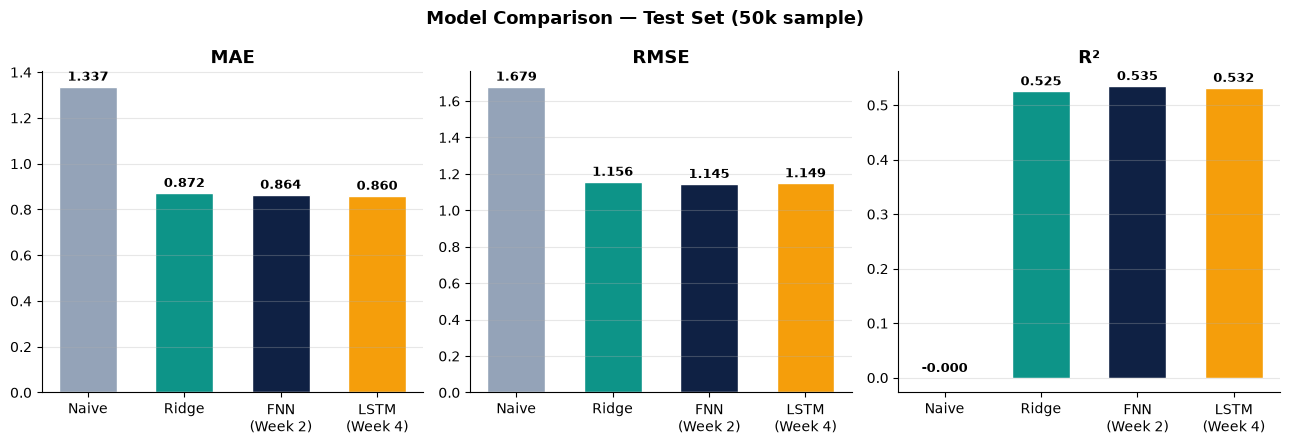

In [7]:
# ── Figure 1: Model comparison bar chart ──────────────────────────────────
lbls   = ["Naive", "Ridge", "FNN\n(Week 2)", "LSTM\n(Week 4)"]
preds  = [pred_naive, pred_ridge, pred_fnn, pred_lstm]
colors = ["#94A3B8", "#0D9488", "#0F2144", "#F59E0B"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, metric in zip(axes, ["MAE", "RMSE", "R²"]):
    vals = [results[k][metric] for k in results]
    bars = ax.bar(range(4), vals, color=colors, edgecolor="white", width=0.6)
    ax.set_xticks(range(4))
    ax.set_xticklabels(lbls, fontsize=10)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+max(vals)*0.01,
                f"{v:.3f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold")

plt.suptitle("Model Comparison — Test Set (50k sample)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/fig_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


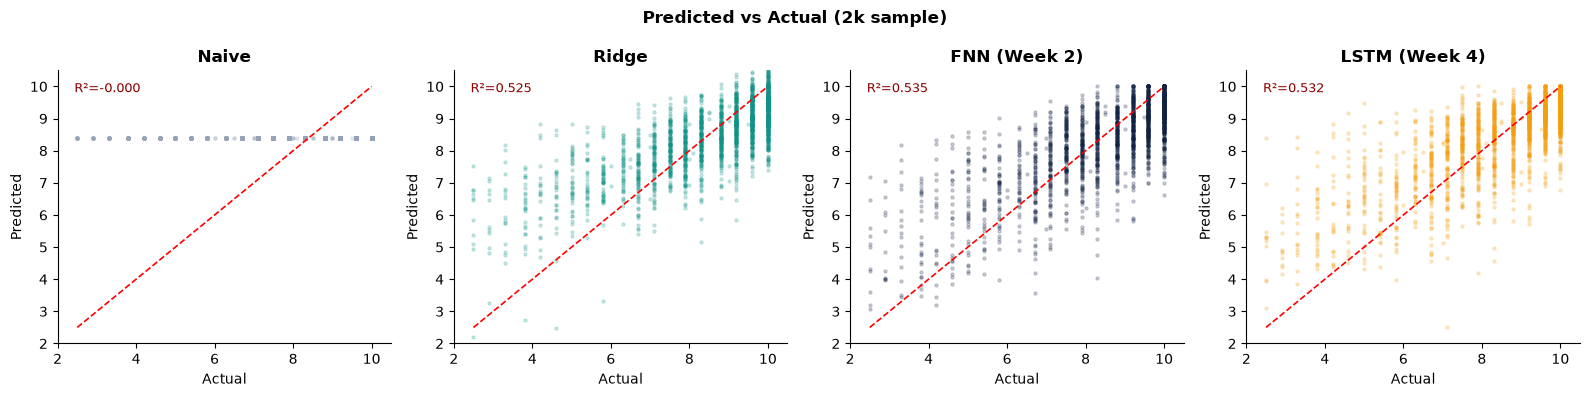

In [8]:
# ── Figure 2: Predicted vs Actual ─────────────────────────────────────────
rng = np.random.default_rng(42)
idx = rng.choice(len(y_test), min(2000, len(y_test)), replace=False)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, pred, label, color in zip(axes, preds, lbls, colors):
    ax.scatter(y_test[idx], pred[idx], alpha=0.2, s=5, color=color)
    ax.plot([2.5,10],[2.5,10],"r--",lw=1.2)
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
    ax.set_title(label.replace("\n"," "), fontweight="bold")
    ax.annotate(f"R²={r2_score(y_test,pred):.3f}",
                xy=(0.05,0.92), xycoords="axes fraction",
                fontsize=9, color="darkred")
    ax.set_xlim(2,10.5); ax.set_ylim(2,10.5)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Predicted vs Actual (2k sample)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("data/fig_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()


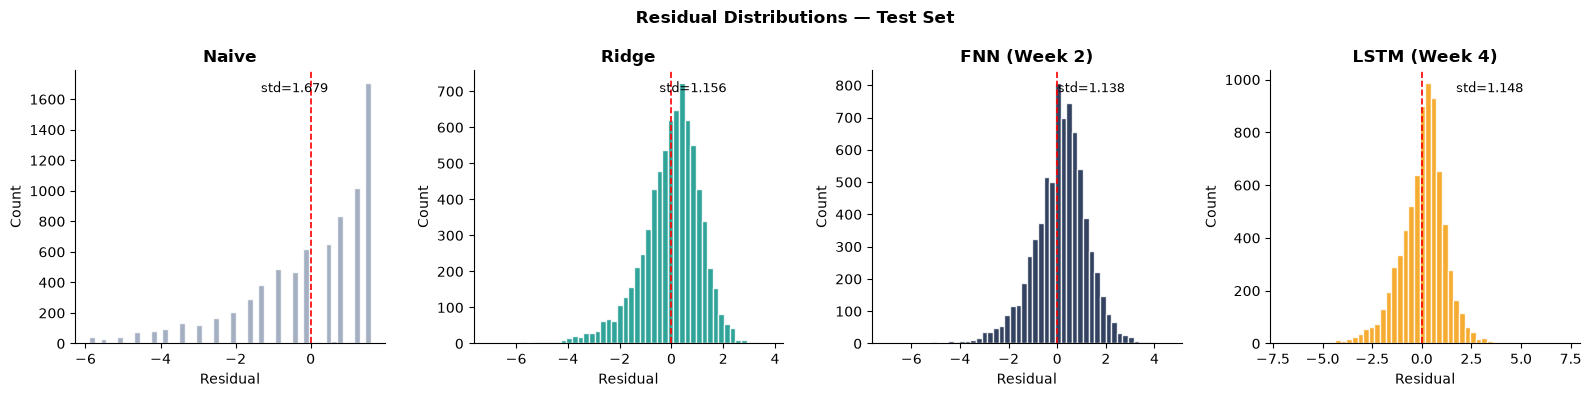

In [9]:
# ── Figure 3: Residual distributions ─────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, pred, label, color in zip(axes, preds, lbls, colors):
    resid = y_test - pred
    ax.hist(resid, bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0, color="red", linestyle="--", lw=1.2)
    ax.set_xlabel("Residual"); ax.set_ylabel("Count")
    ax.set_title(label.replace("\n"," "), fontweight="bold")
    ax.annotate(f"std={resid.std():.3f}",
                xy=(0.60,0.92), xycoords="axes fraction", fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Residual Distributions — Test Set", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("data/fig_residuals.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
# ── Final summary ─────────────────────────────────────────────────────────
print("="*65)
print("FINAL REPORT NUMBERS")
print("="*65)
print(df_res.to_string())
print("\nFigures saved:")
for f in ["fig_model_comparison.png","fig_pred_vs_actual.png",
          "fig_residuals.png"]:
    print(f"  data/{f}")
print("\n(Training curves in data/fig_fnn_training_curves.png")
print("              and data/fig_lstm_training_curves.png)")


FINAL REPORT NUMBERS
                          MAE    RMSE      R²  Within±1
Model                                                  
Naive (mean)           1.3366  1.6788 -0.0003     0.412
Ridge Regression       0.8719  1.1563  0.5255     0.672
FNN + BoW (Week 2)     0.8642  1.1445  0.5351     0.669
LSTM + Embed (Week 4)  0.8597  1.1485  0.5318     0.678

Figures saved:
  data/fig_model_comparison.png
  data/fig_pred_vs_actual.png
  data/fig_residuals.png

(Training curves in data/fig_fnn_training_curves.png
              and data/fig_lstm_training_curves.png)
